<a href="https://colab.research.google.com/github/zaabola/Hackathon-H12/blob/work_done_by_ahmedhbaieb/pipes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELLULE 1 — Téléchargement propre du dataset
# ============================================================
!pip install roboflow ultralytics -q

from roboflow import Roboflow
import os

# Supprimer le dossier corrompu s'il existe
import shutil
if os.path.exists("/content/Pipe-Defects-1"):
    shutil.rmtree("/content/Pipe-Defects-1")
    print("Ancien dossier supprimé.")

# Re-télécharger proprement
rf = Roboflow(api_key="79n595k4hDKPX5HJuPMM")
project = rf.workspace("kev-2du16").project("pipe-defects-2r7wj")
version = project.version(1)
dataset = version.download("yolov11")

print("\nFichiers présents :", os.listdir(dataset.location))
print("data.yaml existe :", os.path.exists(f"{dataset.location}/data.yaml"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pipe-Defects-1 in yolov11:: 100%|██████████| 16206/16206 [00:02<00:00, 7914.47it/s] 


Fichiers présents : ['README.dataset.txt', 'data.yaml', 'README.roboflow.txt', 'train', 'valid', 'test']
data.yaml existe : True


In [2]:
# ============================================================
# CELLULE 2 — Entraînement
# ============================================================
from ultralytics import YOLO

# Vérifier que le yaml existe avant de lancer
yaml_path = f"{dataset.location}/data.yaml"
assert os.path.exists(yaml_path), f"❌ data.yaml introuvable : {yaml_path}"
print(f"✅ data.yaml trouvé : {yaml_path}")

# Vérifier le GPU
import torch
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Device utilisé : {'GPU ✅' if device == 0 else 'CPU ⚠️ (entraînement lent)'}")

# Charger et entraîner
model = YOLO("yolo11n.pt")

results = model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=16 if device == 0 else 4,  # batch réduit sur CPU
    name="pipe-defects-model",
    device=device
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ data.yaml trouvé : /content/Pipe-Defects-1/data.yaml
Device utilisé : GPU ✅
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pipe-Defects-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscri

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


                   all        284        318      0.855      0.919      0.929      0.509
                     -         32         32      0.728      0.921      0.862      0.387
- annotate- and create datasets          3          3      0.787          1      0.995       0.73
- collaborate with your team on computer vision projects         14         16       0.88      0.938      0.911      0.466
- export- train- and deploy computer vision models         18         18      0.932      0.765      0.818      0.356
- understand and search unstructured image data         17         20      0.792       0.85      0.824      0.463
- use active learning to improve your dataset over time          2          2          1      0.764      0.995      0.746
Broken are annotated in YOLO v5 PyTorch format.         87        100      0.797      0.865      0.857      0.375
For state of the art Computer Vision training notebooks you can use with this dataset-         26         26      0.823          1    

✅ Modèle chargé : /content/runs/detect/pipe-defects-model/weights/best.pt

📊 Évaluation sur le set de validation...
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,585,077 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1046.3±380.2 MB/s, size: 23.7 KB)
val: Scanning /content/Pipe-Defects-1/valid/labels.cache... 284 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 284/284 85.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.3it/s 5.5s


Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


                   all        284        318      0.855      0.919      0.928       0.51
                     -         32         32      0.747      0.921      0.863      0.387
- annotate- and create datasets          3          3      0.788          1      0.995       0.73
- collaborate with your team on computer vision projects         14         16       0.88      0.938      0.911      0.466
- export- train- and deploy computer vision models         18         18      0.932      0.766      0.818      0.356
- understand and search unstructured image data         17         20      0.793       0.85      0.824      0.463
- use active learning to improve your dataset over time          2          2          1      0.767      0.995      0.746
Broken are annotated in YOLO v5 PyTorch format.         87        100      0.781      0.855       0.84      0.371
For state of the art Computer Vision training notebooks you can use with this dataset-         26         26      0.823          1    

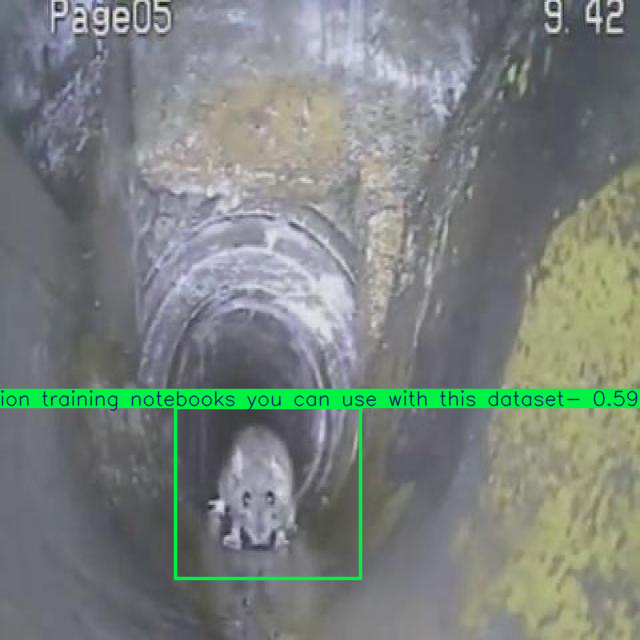


🖼️  Image 2: image1.jpg
   🔴 Broken are annotated in YOLO v5 PyTorch format. — confiance: 0.86 — bbox: [2.8, 0.8, 610.8, 392.5]


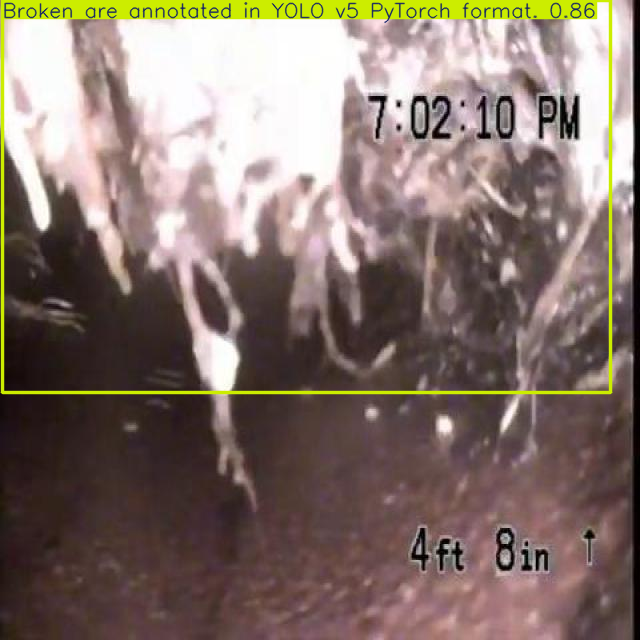


🖼️  Image 3: image2.jpg
   Aucun défaut détecté.


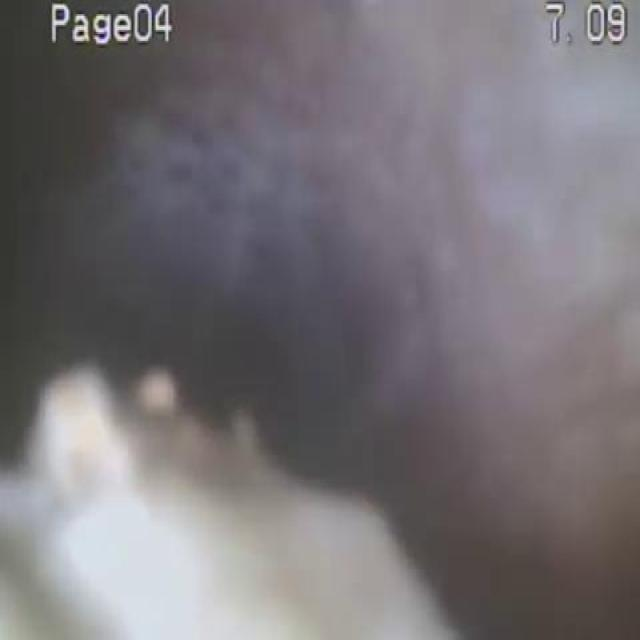


🖼️  Image 4: image3.jpg
   🔴 To find over 100k other datasets and pre-trained models- visit https-universe.roboflow.com — confiance: 0.66 — bbox: [320.3, 352.4, 635.5, 612.8]


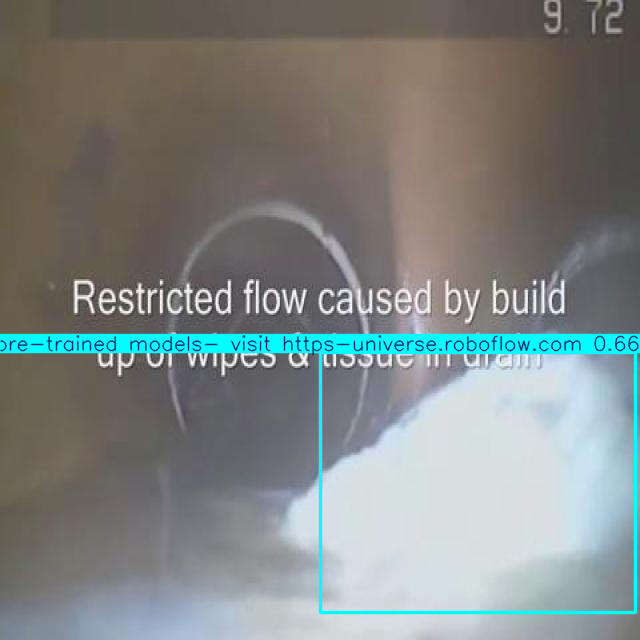


🖼️  Image 5: image4.jpg
   🔴 - — confiance: 0.73 — bbox: [121.2, 117.1, 548.9, 333.8]


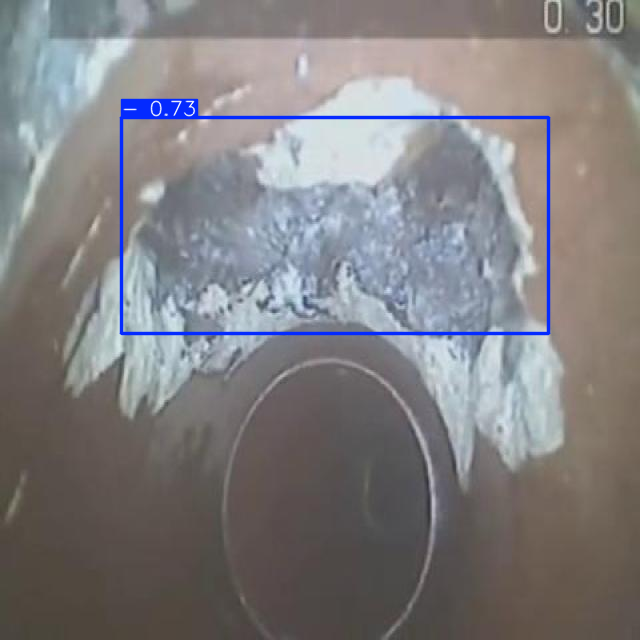


💾 Images annotées sauvegardées dans : /content/runs/detect/pipe-defects-test


In [3]:
# ============================================================
# TEST DU MODÈLE ENTRAÎNÉ
# ============================================================
from ultralytics import YOLO
import os
import glob
from google.colab.patches import cv2_imshow
import cv2

# ============================================================
# 1. Charger le meilleur modèle sauvegardé
# ============================================================
model_path = "/content/runs/detect/pipe-defects-model/weights/best.pt"
assert os.path.exists(model_path), f"❌ Modèle introuvable : {model_path}"
print(f"✅ Modèle chargé : {model_path}")

model = YOLO(model_path)

# ============================================================
# 2. Évaluation sur le set de validation (métriques)
# ============================================================
print("\n📊 Évaluation sur le set de validation...")
metrics = model.val(data=f"{dataset.location}/data.yaml")

print(f"\n📈 Résultats :")
print(f"  mAP50       : {metrics.box.map50:.4f}")
print(f"  mAP50-95    : {metrics.box.map:.4f}")
print(f"  Précision   : {metrics.box.mp:.4f}")
print(f"  Rappel      : {metrics.box.mr:.4f}")

# ============================================================
# 3. Prédiction sur les images de test
# ============================================================
test_images_path = f"{dataset.location}/test/images"
test_images = glob.glob(f"{test_images_path}/*.jpg") + \
              glob.glob(f"{test_images_path}/*.png")

print(f"\n🔍 {len(test_images)} images de test trouvées")

if len(test_images) == 0:
    print("⚠️ Aucune image dans /test/images, on utilise /valid/images")
    test_images_path = f"{dataset.location}/valid/images"
    test_images = glob.glob(f"{test_images_path}/*.jpg") + \
                  glob.glob(f"{test_images_path}/*.png")

# Prédire sur les 5 premières images
results = model.predict(
    source=test_images[:5],
    conf=0.25,       # seuil de confiance
    iou=0.45,        # seuil NMS
    save=True,
    save_conf=True,
    name="pipe-defects-test"
)

# ============================================================
# 4. Afficher les résultats image par image
# ============================================================
for i, result in enumerate(results):
    print(f"\n🖼️  Image {i+1}: {os.path.basename(result.path)}")

    if len(result.boxes) == 0:
        print("   Aucun défaut détecté.")
    else:
        for box in result.boxes:
            cls_id   = int(box.cls)
            label    = model.names[cls_id]
            conf     = float(box.conf)
            coords   = box.xyxy[0].tolist()
            print(f"   🔴 {label} — confiance: {conf:.2f} — bbox: {[round(c,1) for c in coords]}")

    # Afficher l'image annotée dans Colab
    img_annotated = result.plot()
    cv2_imshow(img_annotated)

# ============================================================
# 5. Chemin vers toutes les images sauvegardées
# ============================================================
output_dir = "/content/runs/detect/pipe-defects-test"
print(f"\n💾 Images annotées sauvegardées dans : {output_dir}")